In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import time
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# I. Question 1.

## 1.1 EDA

In [3]:
df = pd.read_excel("/content/drive/MyDrive/K42_Lê Anh Tuấn _ Statistic & ML/churn_prediction.xlsx")
print(df.shape)
df.head(5)

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Mobile Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


In [4]:
# Define the list of columns with missing values
cols_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

# Replace missing columns with median
for col in cols_missing:
    # Fill missing values in each column with the median of that column
    df[col].fillna(value= df[col].median(), inplace=True)

In [5]:
# Merge columns with the same data but different names
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery',  # Replace 'COD' with 'Cash on Delivery'
    'CC': 'Credit Card'  # Replace 'CC' with 'Credit Card'
})

In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [7]:
display(df.describe())

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.223030
std,1625.385339,0.374240,8.357951,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [8]:
# Check missing values in each column
check_missing = df.isna().sum()

# Print the missing values count for each column
print(check_missing)

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


In [9]:
# Check the distribution of continuous variables
continuous_cols = df.select_dtypes(include=['int', 'float64']).columns

# Get the number of unique values in each continuous variable
unique_value_in_continuous_col = df[continuous_cols].nunique()
print(unique_value_in_continuous_col)

CustomerID                     5630
Churn                             2
Tenure                           36
CityTier                          3
WarehouseToHome                  34
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
SatisfactionScore                 5
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64


In [10]:
# Define the list of columns with missing values
cols_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

# Replace missing columns with median
for col in cols_missing:
  df[col].fillna(value= df[col].median(), inplace=True)

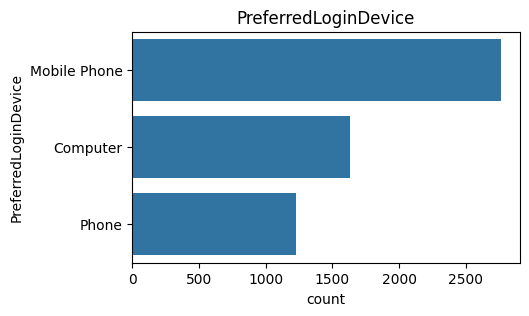

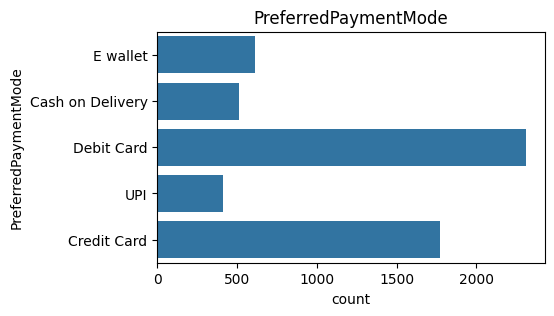

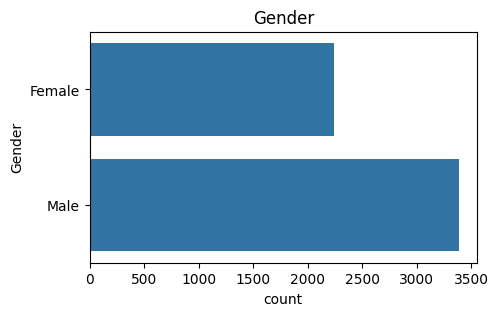

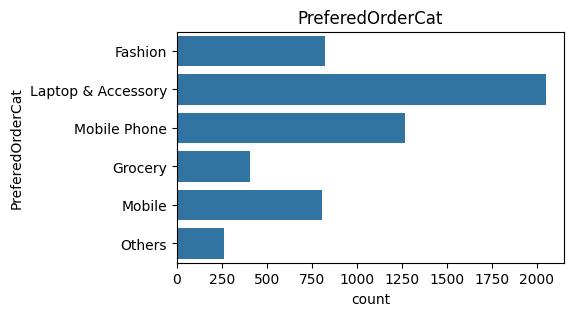

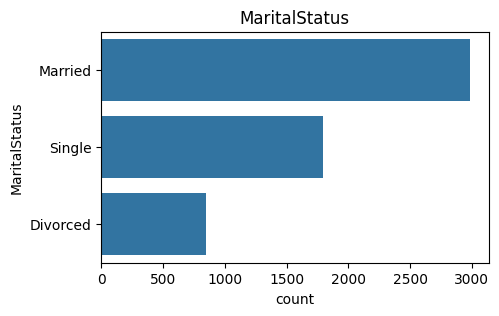

In [11]:
# Select columns with categorical (object) data type
cat_cols = df.select_dtypes(include='object')

# Plot the distribution of values
for col in cat_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(df[col])
  plt.title(col)
  plt.show()


In [12]:
# Merge columns with the same data but different names
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery',  # Replace 'COD' with 'Cash on Delivery'
    'CC': 'Credit Card'  # Replace 'CC' with 'Credit Card'
})

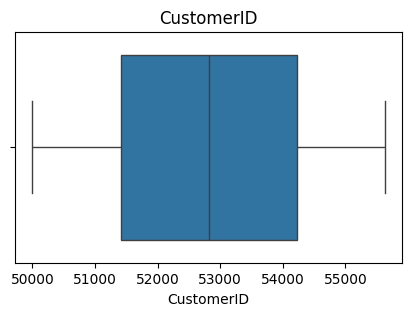

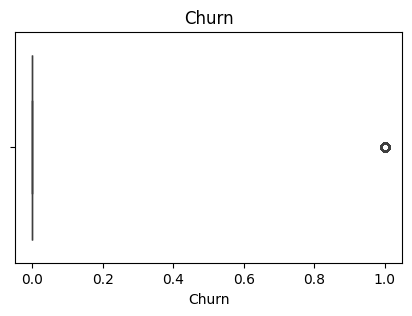

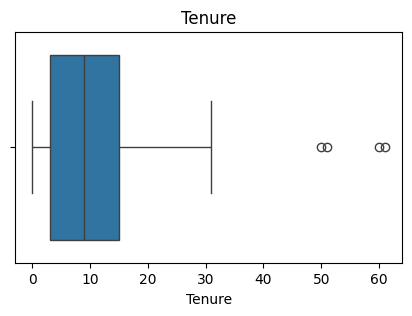

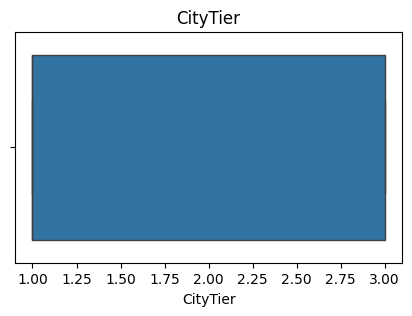

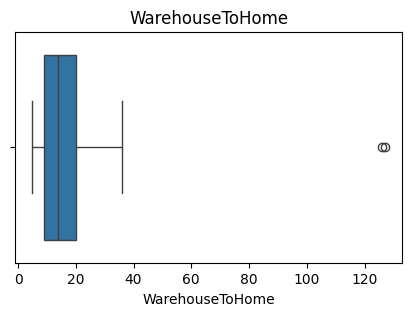

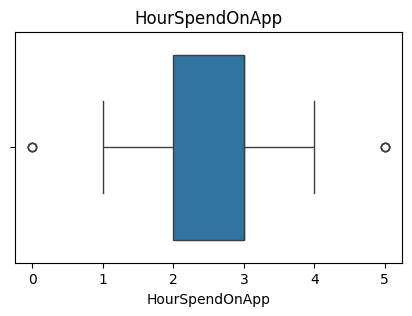

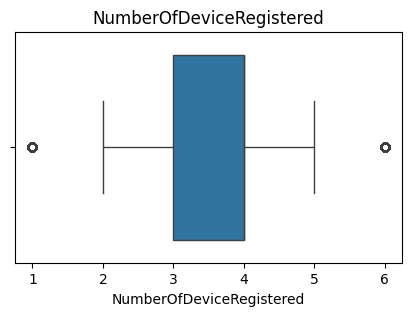

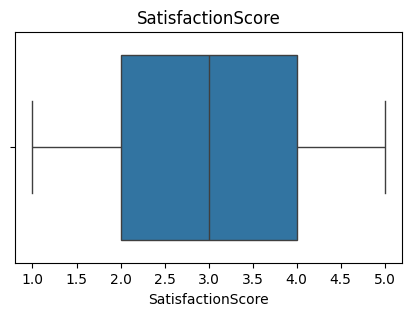

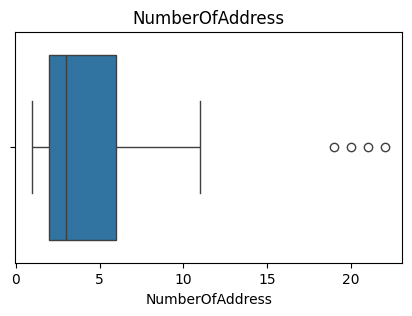

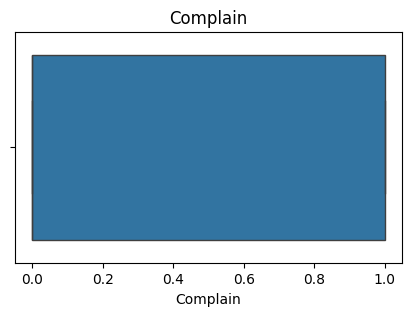

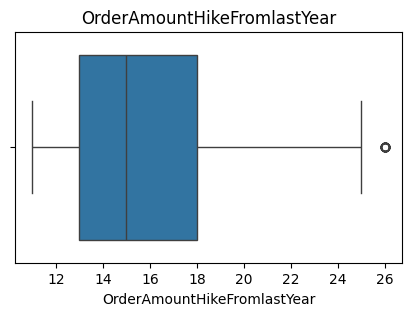

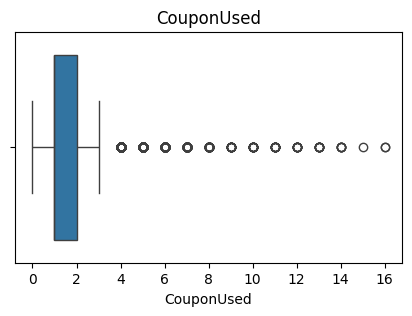

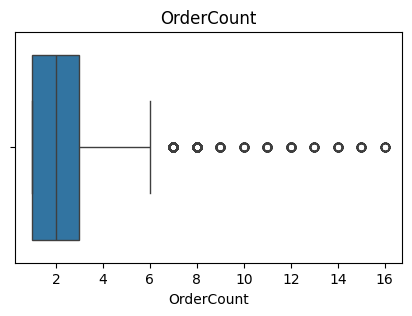

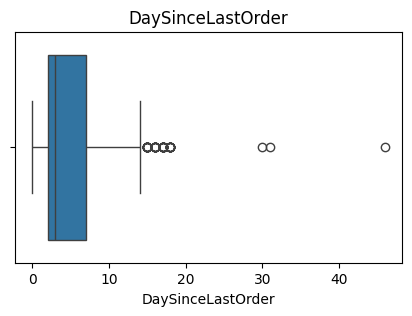

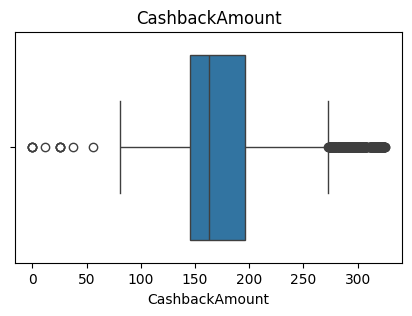

In [13]:
# Plot boxplot to check the distribution of continuous variables
for col in continuous_cols:
  if df[col].dtype in ['int', 'float64']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
# Apply one-hot encoding to categorical columns with a small number of unique values
df_encoded = pd.get_dummies(df, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus', 'PreferredLoginDevice'])

# Apply label encoding to the 'Gender' column (converts categorical labels to numerical values)
label_encoder = LabelEncoder()
df_encoded['Gender'] = label_encoder.fit_transform(df_encoded['Gender'])

# Drop the 'CustomerID'
df_encoded = df_encoded.drop(columns=['CustomerID'])

In [15]:
df_encoded

,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,PreferredLoginDevice_Computer,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone
0,0,20.0,3,7.0,0,4.0,4,5,3,0,...,False,False,False,False,False,True,False,False,True,False
1,0,13.0,1,9.0,0,4.0,4,3,2,0,...,False,False,False,False,False,False,True,True,False,False
2,0,16.0,3,7.0,1,3.0,4,3,3,0,...,True,False,False,False,True,False,False,False,True,False
3,0,5.0,1,16.0,1,3.0,4,4,3,0,...,False,False,False,False,False,True,False,False,True,False
4,0,9.0,1,28.0,0,3.0,4,2,3,1,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,61.0,3,28.0,0,4.0,4,1,6,1,...,False,False,False,False,False,True,False,False,True,False
5626,0,23.0,1,9.0,1,3.0,4,1,5,0,...,False,False,False,True,False,True,False,True,False,False
5627,0,29.0,2,33.0,1,4.0,2,4,6,1,...,False,False,False,True,False,True,False,False,True,False
5628,0,13.0,1,16.0,1,3.0,4,1,4,0,...,False,False,False,True,False,False,True,True,False,False


In [16]:
# Split the data into features (X) and target (y)
x = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']  # Target

# Split into training and testing sets (70/30 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [17]:
# Standardize the features using StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
# Train a Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_scaled, y_train)

# Make predictions on training and test sets
y_pred_train = clf.predict(x_train_scaled)
y_pred_test = clf.predict(x_test_scaled)

In [19]:
# Evaluate model accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_balanced_acc = balanced_accuracy_score(y_train, y_pred_train)
test_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)

# Print the results
print(f'Training Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Training Balanced Accuracy: {train_balanced_acc:.4f}')
print(f'Test Balanced Accuracy: {test_balanced_acc:.4f}')

Training Accuracy: 1.0000
Test Accuracy: 0.9343
Training Balanced Accuracy: 1.0000
Test Balanced Accuracy: 0.8421


In [20]:
# Model đang bị overfitting khi tập train học tốt nhưng bị giảm ở tập test -> Cần fine tune

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [23]:
# n_iter=30 nghĩa là chúng ta chỉ thử 30 bộ tham số ngẫu nhiên thay vì tất cả
random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1 # Chạy song song trên các nhân CPU hiện có
)

print("Đang bắt đầu tìm kiếm tham số tối ưu (Randomized Search)...")
start = time.time()
random_search.fit(x_train_scaled, y_train)
end = time.time()

print(f"Hoàn thành sau: {end - start:.2f} giây")
print("Bộ tham số tốt nhất:", random_search.best_params_)
print("Điểm Balanced Accuracy tốt nhất:", random_search.best_score_)

best_clf = random_search.best_estimator_

Đang bắt đầu tìm kiếm tham số tối ưu (Randomized Search)...
Hoàn thành sau: 56.95 giây
Bộ tham số tốt nhất: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Điểm Balanced Accuracy tốt nhất: 0.8609902519402466


In [24]:
# Đánh giá mô hình tốt nhất tìm được bởi RandomizedSearchCV
# Thay đổi từ grid_search sang random_search
best_clf = random_search.best_estimator_

# Dự đoán trên tập train và test
# Lưu ý: Sử dụng x_train_scaled và x_test_scaled vì model được train trên dữ liệu đã chuẩn hóa
y_train_best_pred = best_clf.predict(x_train_scaled)
y_test_best_pred = best_clf.predict(x_test_scaled)

# Tính toán balanced accuracy
train_balanced_accuracy_best = balanced_accuracy_score(y_train, y_train_best_pred)
test_balanced_accuracy_best = balanced_accuracy_score(y_test, y_test_best_pred)

# In kết quả
print("Train Balanced Accuracy (Best Model): ", train_balanced_accuracy_best)
print("Test Balanced Accuracy (Best Model): ", test_balanced_accuracy_best)

Train Balanced Accuracy (Best Model):  1.0
Test Balanced Accuracy (Best Model):  0.8514875595047675


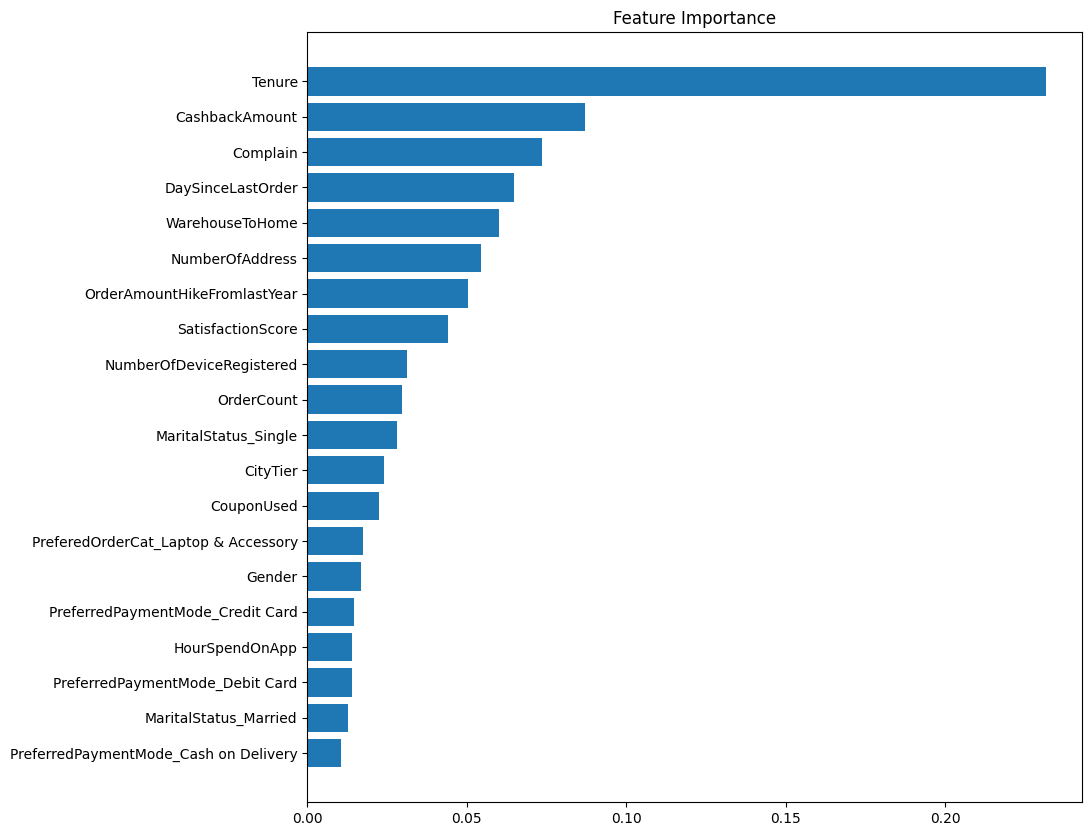

In [25]:
# Get feature importances from the best model
feats = {feature: importance for feature, importance in zip(x_train.columns, best_clf.feature_importances_)}

# Create a DataFrame for feature importances
importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Importances'})
importances = importances.sort_values(by='Importances', ascending=True).reset_index()

# Plot the feature importances
plt.figure(figsize=(10,10))
plt.barh(importances.tail(20)['index'], importances.tail(20)['Importances'])  # Plot top 20 features
plt.title('Feature Importance')
plt.show()

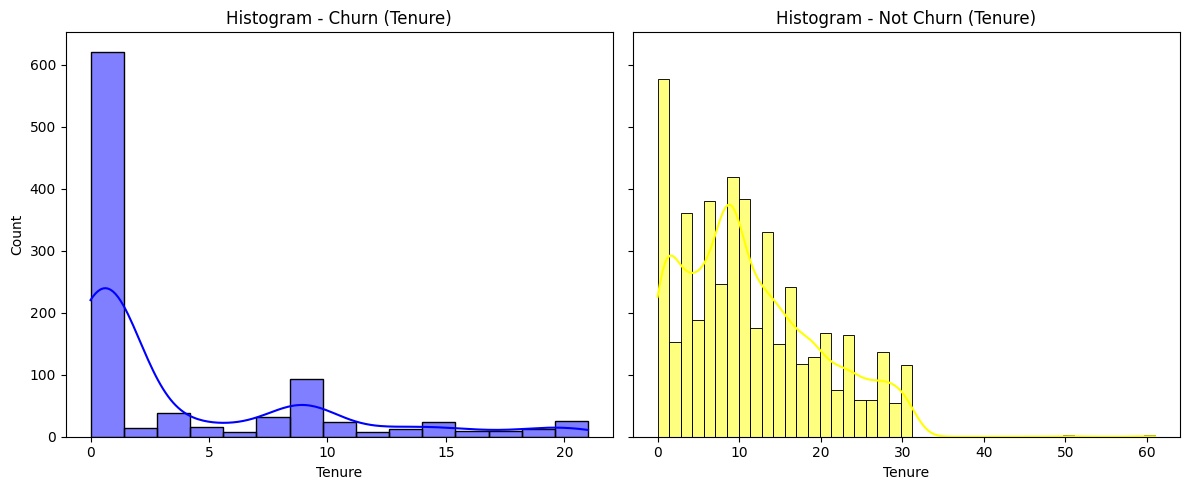

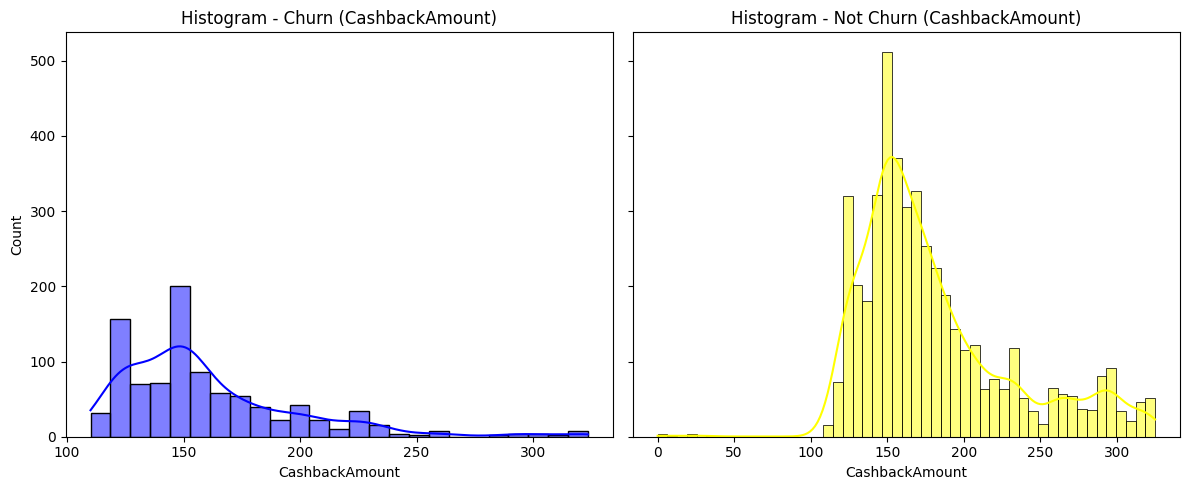

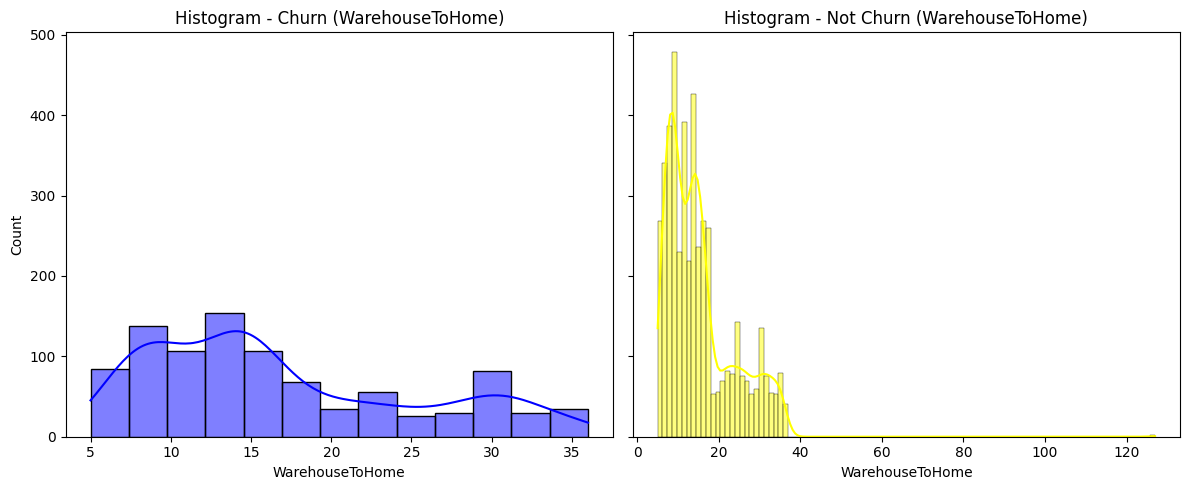

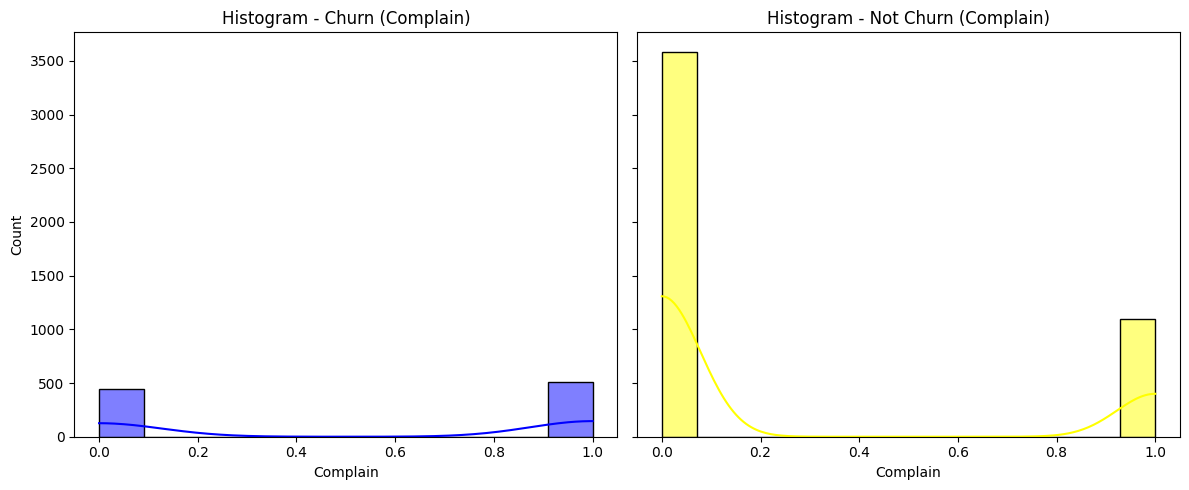

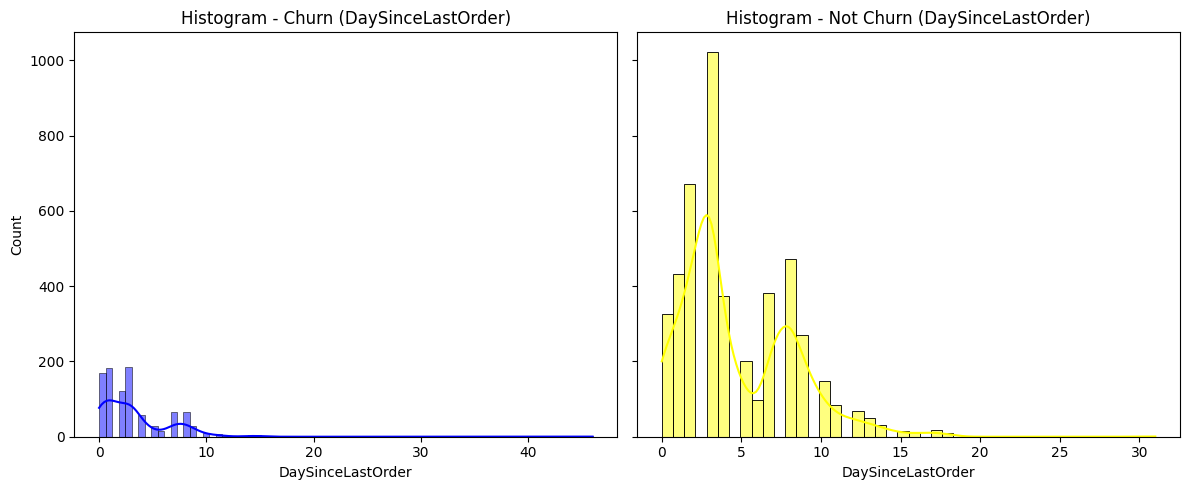

In [27]:
def plot_hist(df, group_column, feature_column, kde=True):
    for column in feature_column:
        # Create subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

        # Filter data for churned and not churned users
        churned_data = df[df[group_column] == 1][column]
        not_churned_data = df[df[group_column] == 0][column]

        # Calculate histogram bins for each group
        bins_churned = np.histogram(churned_data, bins='auto')[1]
        not_bins_churned = np.histogram(not_churned_data, bins='auto')[1]

        # Plot histograms with KDE (Kernel Density Estimation)
        sns.histplot(churned_data, bins=bins_churned, kde=kde, color='blue', ax=axes[0])
        axes[0].set_title(f'Histogram - Churn ({column})')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Count')

        sns.histplot(not_churned_data, bins=not_bins_churned, kde=kde, color='yellow', ax=axes[1])
        axes[1].set_title(f'Histogram - Not Churn ({column})')
        axes[1].set_xlabel(column)
        axes[1].set_ylabel('Count')

        # Adjust layout and display plots
        plt.tight_layout()
        plt.show()

# Define the list of feature columns
feature_column = ["Tenure", "CashbackAmount", "WarehouseToHome", "Complain", "DaySinceLastOrder"]

# Call the function to plot histograms for churned and non-churned users
plot_hist(df, "Churn", feature_column, kde=True)


### **1.4 Insight**

| Metric | Churn (Green) | Non-Churn (Pink) | Insight |
| :--- | :--- | :--- | :--- |
| **Tenure** | 80% rời đi trong vòng 5 tháng đầu, rất ít người ở lại trên 10 tháng. | Phân bổ đều hơn, nhiều khách hàng gắn bó trên 20 tháng. | Khách hàng churn có xu hướng rời đi rất sớm. Trải nghiệm ban đầu là cực kỳ quan trọng. |
| **CashbackAmount** | Trung bình khoảng 100-200, phân bổ rộng. | Tập trung chủ yếu từ 120-250. | Khách hàng churn nhận được ít hoàn tiền hơn, có thể dẫn đến cảm giác lợi ích tài chính thấp. |
| **WarehouseToHome** | Phân bổ rộng, trung bình 15-30 ngày, một số trên 35 ngày. | Hầu hết dưới 20 ngày, hiếm khi quá 25 ngày. | Thời gian giao hàng dài tương quan với tỷ lệ churn cao. Tối ưu hóa logistics là cần thiết. |
| **Complain** | Khoảng 50% khách hàng churn có khiếu nại. | Đa số không khiếu nại, chỉ khoảng 10-15% có khiếu nại. | Tỷ lệ khiếu nại ở nhóm churn cao vượt trội, nhưng vẫn có nhóm âm thầm rời đi mà không phản hồi. |
| **DaySinceLastOrder** | Phân bổ rộng, đa số trên 10 ngày, nhiều người trên 20 ngày. | Hầu hết dưới 10 ngày. | Khách hàng ít đặt hàng thường xuyên có nguy cơ rời đi cao hơn. |

#### **Key Takeaways**
1. **Trải nghiệm ban đầu là chìa khóa:** Cần tập trung giữ chân khách hàng ngay trong 5 tháng đầu tiên.
2. **Ưu đãi tài chính:** Cân nhắc điều chỉnh chính sách cashback hoặc phần thưởng thay thế cho nhóm khách hàng mới.
3. **Logistics:** Cần rút ngắn thời gian giao hàng từ kho đến nhà để giảm rủi ro khách hàng rời bỏ.
4. **Chủ động chăm sóc khách hàng:** Vì nhiều người churn mà không khiếu nại, cần các khảo sát chủ động để nắm bắt sự không hài lòng sớm hơn.
5. **Kích cầu mua sắm lại:** Áp dụng các mã giảm giá có thời hạn để khuyến khích khách hàng đặt đơn tiếp theo sớm hơn.

### **1.5 Đề xuất chiến lược từ EDA (Recommendations)**

Dựa trên các insight từ dữ liệu, doanh nghiệp nên thực hiện các hành động sau:

1.  **Chiến dịch 'Gắn kết sớm' (Early Engagement):**
    *   Vì 80% khách hàng rời đi trong 5 tháng đầu, cần tập trung tối đa nguồn lực chăm sóc vào giai đoạn này.
    *   Tự động hóa gửi email/tin nhắn hướng dẫn và ưu đãi đặc quyền cho khách hàng mới mỗi tuần trong 2 tháng đầu tiên.

2.  **Tối ưu hóa Phí và Ưu đãi Tài chính:**
    *   Rà soát lại mức Cashback cho nhóm khách hàng mới để đảm bảo tính cạnh tranh.
    *   Thiết kế các gói combo hoặc chương trình tích điểm có giá trị tích lũy nhanh ở giai đoạn đầu để khách hàng thấy được lợi ích tài chính rõ rệt.

3.  **Cải thiện chất lượng Vận hành & Logistics:**
    *   Thiết lập cảnh báo hệ thống cho các đơn hàng có thời gian giao dự kiến trên 20 ngày.
    *   Ưu tiên xử lý các đơn hàng của nhóm khách hàng có nguy cơ churn cao hoặc khách hàng mới để đảm bảo trải nghiệm giao nhận tốt nhất.

4.  **Hệ thống Phản hồi Chủ động (Proactive Feedback):**
    *   Đừng đợi khách hàng khiếu nại (Complain). Xây dựng khảo sát nhanh (1-2 câu hỏi) ngay sau khi khách hàng nhận đơn hàng thứ 2 hoặc khi họ không quay lại app sau 10 ngày.

5.  **Chính sách Kích cầu Mua sắm (Re-activation):**
    *   Đối với khách hàng không phát sinh đơn hàng trong 7-10 ngày, gửi mã giảm giá có thời hạn ngắn (Flash coupon) để thúc đẩy hành vi đặt hàng trở lại sớm nhất có thể.

## **Question 2: Phân tích và Xây dựng mô hình với các biến quan trọng nhất**

### 1. Phân tách và Chuẩn hóa dữ liệu với Top 5 Features

In [28]:
import time
from sklearn.metrics import recall_score

# Lấy 5 biến quan trọng nhất
top_features = ['Tenure', 'CashbackAmount', 'WarehouseToHome', 'Complain', 'DaySinceLastOrder']
x_q2 = df_encoded[top_features]
y_q2 = df_encoded['Churn']

# Chia tập dữ liệu (70% train, 15% validation, 15% test)
x_train_q2, x_temp, y_train_q2, y_temp = train_test_split(x_q2, y_q2, test_size=0.3, random_state=42)
x_val_q2, x_test_q2, y_val_q2, y_test_q2 = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# Chuẩn hóa
scaler_q2 = StandardScaler()
x_train_q2_scaled = scaler_q2.fit_transform(x_train_q2)
x_val_q2_scaled = scaler_q2.transform(x_val_q2)
x_test_q2_scaled = scaler_q2.transform(x_test_q2)

print(f"Kích thước tập Train: {x_train_q2.shape}")
print(f"Kích thước tập Val: {x_val_q2.shape}")
print(f"Kích thước tập Test: {x_test_q2.shape}")

Kích thước tập Train: (3941, 5)
Kích thước tập Val: (844, 5)
Kích thước tập Test: (845, 5)


### 2. Huấn luyện và So sánh Recall Score giữa các mô hình

Random Forest - Recall trên tập Validation: 0.6980
Logistic Regression - Recall trên tập Validation: 0.3289
KNN - Recall trên tập Validation: 0.4698
XGBoost - Recall trên tập Validation: 0.5906
Gradient Boosting - Recall trên tập Validation: 0.5168


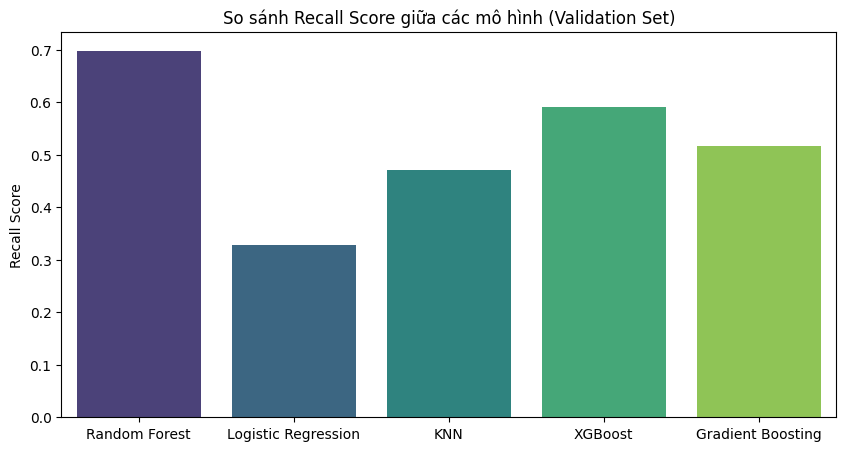

In [29]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(x_train_q2_scaled, y_train_q2)
    y_val_pred = model.predict(x_val_q2_scaled)
    recall = recall_score(y_val_q2, y_val_pred)
    results[name] = recall
    print(f"{name} - Recall trên tập Validation: {recall:.4f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('So sánh Recall Score giữa các mô hình (Validation Set)')
plt.ylabel('Recall Score')
plt.show()

### 3. Tối ưu hóa (Fine-tune) và Đánh giá cuối cùng mô hình Random Forest

Đang tối ưu hóa Random Forest...
Tham số tốt nhất: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}

KẾT QUẢ TRÊN TẬP TEST:
Recall: 0.8170
Precision: 0.8562
F1-score: 0.8361


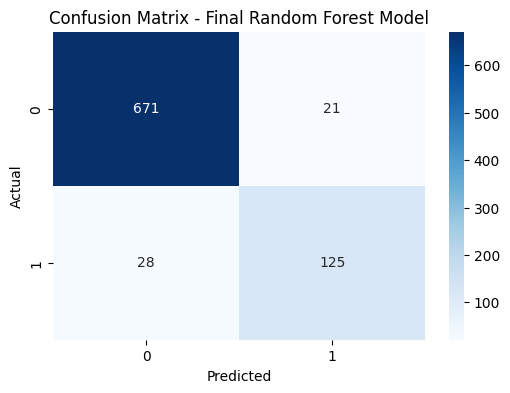

In [30]:
# Thiết lập lưới tham số để tinh chỉnh Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Sử dụng RandomizedSearchCV để tìm bộ tham số tốt nhất tối ưu cho Recall
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

print("Đang tối ưu hóa Random Forest...")
random_search_rf.fit(x_train_q2_scaled, y_train_q2)

# Lấy mô hình tốt nhất
best_rf_q2 = random_search_rf.best_estimator_
print(f"Tham số tốt nhất: {random_search_rf.best_params_}")

# Dự đoán trên tập Test
y_test_pred_q2 = best_rf_q2.predict(x_test_q2_scaled)

# Đánh giá chi tiết
final_recall = recall_score(y_test_q2, y_test_pred_q2)
final_precision = precision_score(y_test_q2, y_test_pred_q2)
final_f1 = f1_score(y_test_q2, y_test_pred_q2)
cm_q2 = confusion_matrix(y_test_q2, y_test_pred_q2)

print(f"\nKẾT QUẢ TRÊN TẬP TEST:")
print(f"Recall: {final_recall:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"F1-score: {final_f1:.4f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_q2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Random Forest Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
Recall Score: 0.8170
Precision Score: 0.8562
F1 Score: 0.8361


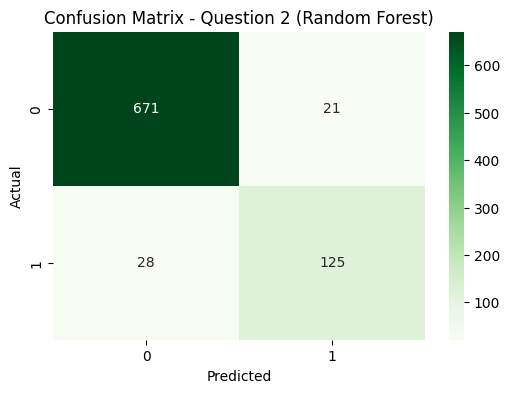

In [32]:
# Đánh giá cuối cùng trên tập Test
y_test_pred_q2 = best_rf_q2.predict(x_test_q2_scaled)

# Tính toán các chỉ số
final_recall = recall_score(y_test_q2, y_test_pred_q2)
final_precision = precision_score(y_test_q2, y_test_pred_q2)
final_f1 = f1_score(y_test_q2, y_test_pred_q2)
final_cm = confusion_matrix(y_test_q2, y_test_pred_q2)

print("--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(f"Recall Score: {final_recall:.4f}")
print(f"Precision Score: {final_precision:.4f}")
print(f"F1 Score: {final_f1:.4f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Question 2 (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **Question 3: Phân cụm khách hàng (Customer Segmentation)**


In [33]:
df_churned = df[df['Churn'] == 1].copy()
print(f"Số lượng khách hàng churned: {df_churned.shape[0]}")
df_churned.head()

Số lượng khách hàng churned: 948


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
7,53583,1,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Mobile Phone,4,Single,3,1,26.0,2.0,2.0,1.0,143.59
24,55053,1,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Mobile Phone,4,Single,3,1,26.0,1.0,2.0,1.0,143.59
40,50768,1,9.0,Computer,1,16.0,Credit Card,Female,3.0,4,Mobile Phone,4,Single,2,1,25.0,1.0,1.0,0.0,118.59
58,52238,1,9.0,Computer,1,16.0,Credit Card,Female,3.0,4,Mobile Phone,4,Single,2,1,25.0,0.0,1.0,0.0,118.59
68,52834,1,1.0,Computer,1,14.0,Debit Card,Male,4.0,6,Laptop & Accessory,3,Single,3,1,25.0,2.0,2.0,7.0,185.74


In [34]:
# One-hot encoding
df_churned_encoded = pd.get_dummies(df_churned,
                                    columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus'])
# Label encoding
le = LabelEncoder()
df_churned_encoded.loc[:, 'Gender'] = le.fit_transform(df_churned_encoded['Gender'])

In [35]:
# Normalize data
scaler = RobustScaler()
df_churned_final = scaler.fit_transform(df_churned_encoded)

In [36]:
# Initialize PCA with 90% variance retention
pca = PCA(n_components=0.90)

# Apply PCA transformation to the dataset
pca_final = pca.fit_transform(df_churned_final)

# Print the number of principal components retained
print(f'Number of principal components retained: {pca_final.shape[1]}')

# Print the explained variance ratio for each principal component
pca.explained_variance_ratio_

Number of principal components retained: 16


array([0.37453996, 0.08135524, 0.06553578, 0.05504876, 0.04071252,
       0.03818099, 0.03680896, 0.03256237, 0.03065416, 0.02930572,
       0.02572048, 0.0217746 , 0.02007918, 0.01874905, 0.01681913,
       0.01584104])

In [37]:
# Convert PCA into dataframe
pca_df = pd.DataFrame(pca_final, columns=[f"col{i+1}" for i in range(pca_final.shape[1])])
pca_df.head()

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16
0,-0.313564,1.202533,1.234286,-1.733841,1.123337,-0.502943,-0.248539,-0.307540,0.071523,-0.416252,-0.224674,0.401305,-0.368937,-0.592663,0.726531,-0.061401
1,-1.044865,0.667937,1.288572,-1.933136,1.178064,-0.710274,0.164051,-0.298379,0.038295,-0.372064,-0.194300,0.425825,-0.457942,-0.538373,0.768711,-0.006692
2,-1.585230,1.092800,0.200376,-0.609120,1.730919,-0.639652,-0.680237,-0.360163,0.477145,-0.355772,-0.457747,0.345623,-0.696350,-0.381884,0.400699,0.253732
3,-2.316531,0.558203,0.254662,-0.808416,1.785645,-0.846984,-0.267647,-0.351002,0.443917,-0.311584,-0.427373,0.370143,-0.785354,-0.327595,0.442880,0.308441
4,0.500618,-0.461943,0.708676,-1.877334,0.203592,-0.506353,-1.047490,-0.678437,0.523057,-0.890235,0.416008,0.569106,0.472145,-0.681171,0.343442,-0.419447


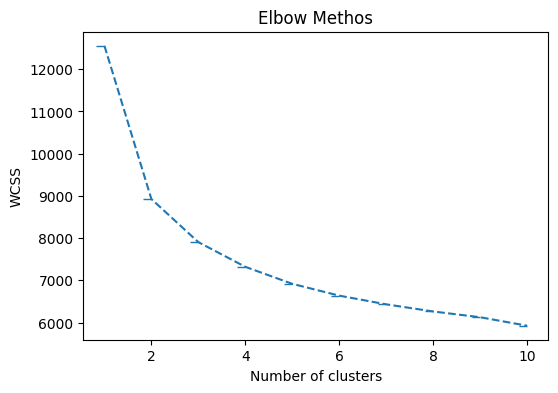

In [38]:
#Calculate KMeans
from sklearn.cluster import KMeans
ss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, n_init=10, random_state=42, init='k-means++')
  kmeans.fit(pca_df)
  ss.append(kmeans.inertia_)

#Plot the Elbow
plt.figure(figsize = (6,4))
plt.plot(range(1,11), ss, marker=0, linestyle='--')
plt.title('Elbow Methos')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [39]:
# Initialize KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, init='k-means++')

# Apply KMeans and get predicted labels
predicted_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to dataframes
pca_df['cluster'] = predicted_labels
df_churned_encoded['cluster'] = predicted_labels
df_churned['cluster'] = predicted_labels

In [40]:
# Calculate and print silhouette score
sil_score = silhouette_score(pca_df, predicted_labels)
print(sil_score)

0.16964175320877975


### **Nhận xét về kết quả PCA và Clustering**

- **PCA:** Không giữ được ý nghĩa quan trọng của dữ liệu (tổng tỷ lệ phương sai giải thích được quá thấp).
- **Elbow Method:** Khi áp dụng phương pháp Khuỷu tay, không thấy rõ điểm gãy (elbow points) cụ thể nào.
- **Giả thuyết:** Dữ liệu có tính phân tán cao, nghĩa là không có các mẫu (patterns) rõ rệt giữa các điểm dữ liệu, do đó việc phân cụm thành các nhóm riêng biệt là rất thách thức.
- **Silhouette Score:** Chỉ số Silhouette cũng thấp, cho thấy các cụm không được tách biệt tốt.

**Gợi ý:**
Nên sử dụng các phương pháp phân cụm không yêu cầu số lượng cụm cố định. Chúng ta có thể thử mô hình **Hierarchical Clustering** (Phân cụm phân cấp), mô hình này có thể cung cấp các cụm được xác định tốt hơn mà không cần xác định trước số lượng cụm.

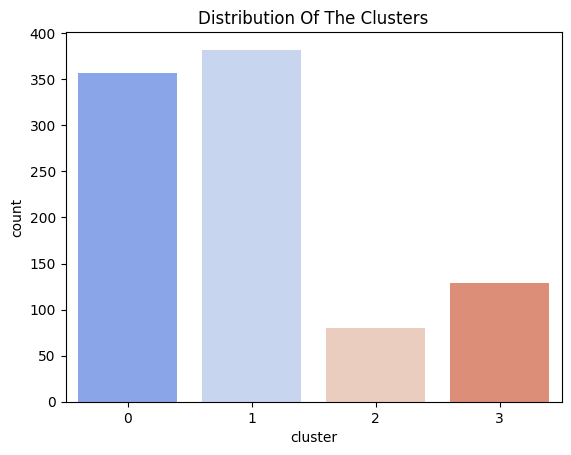

In [41]:
# Plot the distribution of clusters
pl = sns.countplot(x=df_churned["cluster"], palette='coolwarm')
pl.set_title("Distribution Of The Clusters")
plt.show()

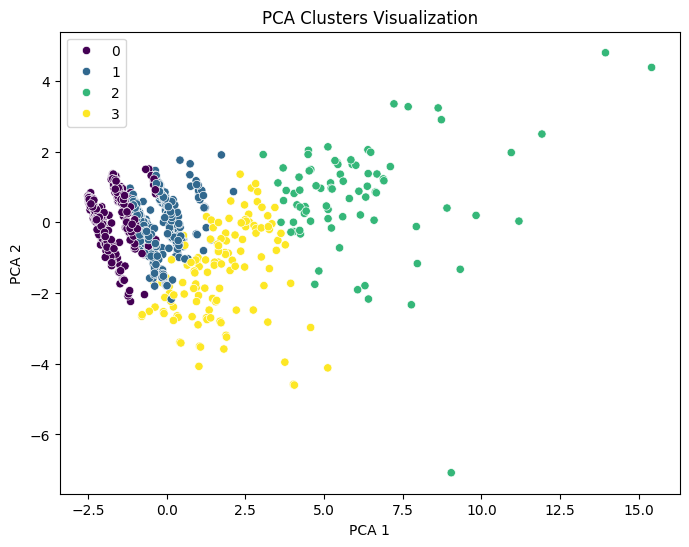

In [42]:
# Visualize the clusters in 2D PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_df.values[:,0], y=pca_df.values[:,1], hue=predicted_labels, palette='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Clusters Visualization")
plt.show()

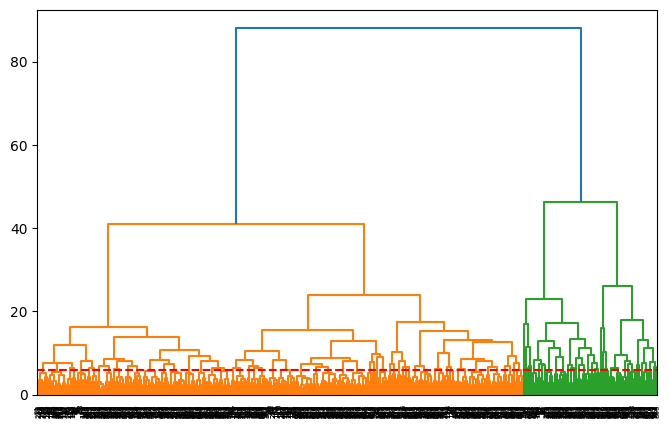

In [43]:
X_pca = pca_df.values

# Draw dendrogram
plt.figure(figsize=(8, 5))
dendrogram = sch.dendrogram(sch.linkage(X_pca, method='ward'))
plt.axhline(y=6, color='r', linestyle='--')
plt.show()

Silhouette Score: 0.32238739179773573


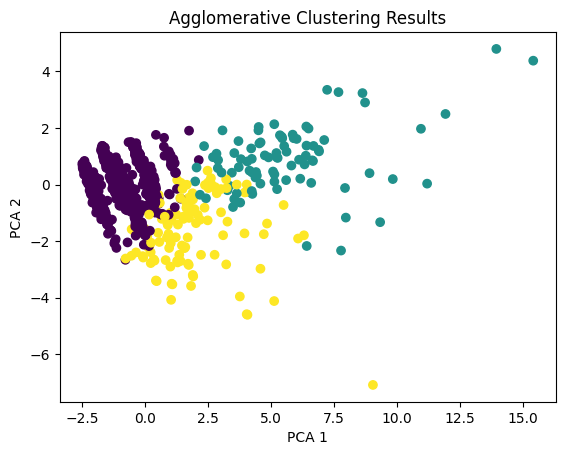

In [44]:
# Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(n_clusters=3)
clusters = agg_clustering.fit_predict(pca_df)

# Calculate the Silhouette Score
sil_score = silhouette_score(pca_df, clusters)
print(f"Silhouette Score: {sil_score}")

# Visualize the clusters (if pca_df is 2D or 3D)
plt.scatter(pca_df.iloc[:, 0], pca_df.iloc[:, 1], c=clusters, cmap='viridis')
plt.title('Agglomerative Clustering Results')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()